In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
import os
import time
from skimage.segmentation import felzenszwalb
from helpers import get_stats, get_imgs, average_stats, printer, showResult
from distortions import distortions, post_process

In [2]:
# Obtains mask after felzenszwalb has been used to obtain segments
def felzenszwalb_mask(img, segments):
    h, w = np.shape(segments)
    
    # Convert to Lab colour space
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    # Obtain number of unique segments in felzenszwalb
    num_segments = len(np.unique(segments))

    # Store mean of L, a, b values for each segment
    segment_values = np.zeros((num_segments, 3))
    
    # Compute mean Lab color per segment
    for x in range(num_segments):
        segment_values[x, :] = np.mean(img_lab[segments == x], axis=0)
            
    # obtain a axis of Lab (green-red scale)
    a_axis = segment_values[:, 1].astype(np.float32)
            
    # Normalize to allow thresholding
    a_axis = cv2.normalize(a_axis, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Convert array into 2D (num_segments x 1)
    # Otsu threshold to split into 2 groups automatically
    _, thresh = cv2.threshold(a_axis.reshape(-1, 1),0, 1,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Convert back into array
    lookup = thresh.flatten().astype(np.uint8)
                
    # Replace each value of segments with obtained thresholded 0 or 1 then generate mask
    mask = 255 * lookup[segments]
    return mask

In [3]:
train_path = Path("../Data/EWS-Dataset/train")
validate_path = Path("../Data/EWS-Dataset/validation")
test_path = Path("../Data/EWS-Dataset/test")

In [4]:
# Obtain images and labels from dataset
trn_imgs, trn_labels = get_imgs(train_path)
vld_imgs, vld_labels = get_imgs(validate_path)
tst_imgs, tst_labels = get_imgs(test_path)

# Merge training and validation data as advanced segmentation does not require training
vld_imgs = trn_imgs + vld_imgs
vld_labels = trn_labels + vld_labels

In [5]:
# Variables to validate over (tuned subset of larger grid search)
scale = [10, 20, 50]
sigma = [0, 0.5]
min_size = [3, 10]

In [6]:
# Validation testing
# Setup (test 20 randomly sampled points for speed)
stats = np.zeros((len(scale), len(sigma), len(min_size),5))
time_start = time.perf_counter()
subset = np.random.choice(len(vld_imgs), size=20, replace=False)
subset_imgs = [vld_imgs[i] for i in subset]
subset_labels = [vld_labels[i] for i in subset]

for i in range(len(scale)):
    for j in range(len(sigma)):
        for k in range(len(min_size)):
            stat_holder = np.zeros((len(subset_imgs), 5))
            for count in range(len(subset_imgs)):
                img = cv2.imread(subset_imgs[count])
                
                # Felzenszwalb returns regions of different labels
                segments = felzenszwalb(img, scale=scale[i], sigma=sigma[j], min_size=min_size[k])
                mask = felzenszwalb_mask(img, segments)
                
                # Obtain label and check stats
                label = cv2.imread(subset_labels[count], cv2.IMREAD_GRAYSCALE)
                _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
                acc, recall, precision, IoU, f1 = get_stats(mask, label)
                stat_holder[count, :] = (acc, recall, precision, IoU, f1)
        
            stats[i, j, k, :] = (np.mean(stat_holder[:,0]), np.mean(stat_holder[:,1]), 
                                 np.mean(stat_holder[:,2]), np.mean(stat_holder[:,3]), np.mean(stat_holder[:,4]))

time_end = time.perf_counter()

In [7]:
# Results of hyperparameter validation
print("Hyperparameter validation results outcomes")
print(stats)
print(f"Time taken for validation: {time_end - time_start} seconds")

Hyperparameter validation results outcomes
[[[[0.89667755 0.85605086 0.73886665 0.64915745 0.75999382]
   [0.90961878 0.80687713 0.79209692 0.65954035 0.77655775]]

  [[0.89621347 0.85973781 0.73138867 0.64481274 0.75757141]
   [0.9086702  0.81199774 0.7872362  0.66032709 0.77754773]]]


 [[[0.89826204 0.85401327 0.72613073 0.63797192 0.75519307]
   [0.90784286 0.81201494 0.78216621 0.65614228 0.77483748]]

  [[0.89700367 0.85027028 0.71495701 0.62349251 0.74477118]
   [0.90664286 0.81280047 0.76935977 0.64744845 0.76945385]]]


 [[[0.88743796 0.84412183 0.68877147 0.60010515 0.72622659]
   [0.89822857 0.8150845  0.73288281 0.62234398 0.75087378]]

  [[0.8795     0.8286662  0.67445503 0.57944145 0.71092275]
   [0.88822612 0.80062101 0.70919723 0.59468311 0.72865441]]]]
Time taken for validation: 338.4917890999932 seconds


In [8]:
# Apply model to test data
images = []
labels = []
masks = []

# Stats for each test image
tst_stats = np.zeros((len(tst_imgs), 5))

time_start = time.perf_counter()
for i in range(len(tst_imgs)):
    img = cv2.imread(tst_imgs[i])

    # Apply felzenszwalb with hyperparameters from validation
    segments = felzenszwalb(img, scale=scale[0], sigma=sigma[0], min_size=min_size[1])

    mask = felzenszwalb_mask(img, segments)

    # Obtain label and check stats
    label = cv2.imread(tst_labels[i], cv2.IMREAD_GRAYSCALE)
    _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
    acc, recall, precision, IoU, f1 = get_stats(mask, label)
    tst_stats[i, :] = (acc, recall, precision, IoU, f1)

    images.append(img)
    labels.append(label)
    masks.append(mask)
    
time_end = time.perf_counter()
stats_avg = average_stats(tst_stats)
printer("Average", stats_avg)
print(f"Total test time: {time_end - time_start} seconds")

Average Test Accuracy: 0.8889472789115648
Average Test Recall: 0.836874824589069
Average Test Precision: 0.7383823002139916
Average Test IoU: 0.6475116517199471
Average Test F1 score: 0.7510619593010466
Total test time: 24.753298999974504 seconds


In [9]:
# Apply post-processing
process = []
pro_tst_stats = np.zeros((len(tst_imgs), 5))
for i in range(len(tst_imgs)):
    processed = post_process(masks[i])
    process.append(processed)
    acc, recall, precision, IoU, f1 = get_stats(processed, labels[i])
    pro_tst_stats[i, :] = (acc, recall, precision, IoU, f1)

pro_stats_avg = average_stats(pro_tst_stats)
printer("Average Post-Processed", pro_stats_avg)

Average Post-Processed Test Accuracy: 0.9003353741496598
Average Post-Processed Test Recall: 0.7971137381082212
Average Post-Processed Test Precision: 0.7734530606173475
Average Post-Processed Test IoU: 0.6500444779758914
Average Post-Processed Test F1 score: 0.7559509872636238


In [10]:
# Apply distortions to test set and retest
transform = distortions()
aug_imgs = []
aug_labels = []
for i in range(len(tst_imgs)):
    transformed = transform(image=images[i], mask=labels[i])
    aug_imgs.append(transformed["image"])
    aug_labels.append(transformed["mask"])

In [11]:
# Test on distorted data
aug_masks = []
aug_tst_stats = np.zeros((len(tst_imgs), 5))

time_start = time.perf_counter()
for i in range(len(aug_imgs)):
    segments = felzenszwalb(aug_imgs[i], scale=scale[0], sigma=sigma[0], min_size=min_size[1])
    mask = felzenszwalb_mask(aug_imgs[i], segments)

    acc, recall, precision, IoU, f1 = get_stats(mask, aug_labels[i])
    aug_tst_stats[i, :] = (acc, recall, precision, IoU, f1)

    aug_masks.append(mask)

time_end = time.perf_counter()
aug_stats_avg = average_stats(aug_tst_stats)

printer("Average Distorted", aug_stats_avg)
print(f"Total test time: {time_end - time_start} seconds")

Average Distorted Test Accuracy: 0.7331761904761905
Average Distorted Test Recall: 0.7029182062052345
Average Distorted Test Precision: 0.5855491226683228
Average Distorted Test IoU: 0.44449938056944555
Average Distorted Test F1 score: 0.5727116004467506
Total test time: 22.45795009995345 seconds


In [12]:
# Post processing for the distorted data test set
aug_process = []
aug_pro_tst_stats = np.zeros((len(tst_imgs), 5))
for i in range(len(tst_imgs)):
    processed = post_process(aug_masks[i])
    aug_process.append(processed)
    acc, recall, precision, IoU, f1 = get_stats(processed, aug_labels[i])
    aug_pro_tst_stats[i, :] = (acc, recall, precision, IoU, f1)

aug_pro_stats_avg = average_stats(aug_pro_tst_stats)
printer("Average Post-Processed Distorted", aug_pro_stats_avg)

Average Post-Processed Distorted Test Accuracy: 0.7560234693877551
Average Post-Processed Distorted Test Recall: 0.6430004915229576
Average Post-Processed Distorted Test Precision: 0.626044541344812
Average Post-Processed Distorted Test IoU: 0.43752124097190787
Average Post-Processed Distorted Test F1 score: 0.5649858184081972


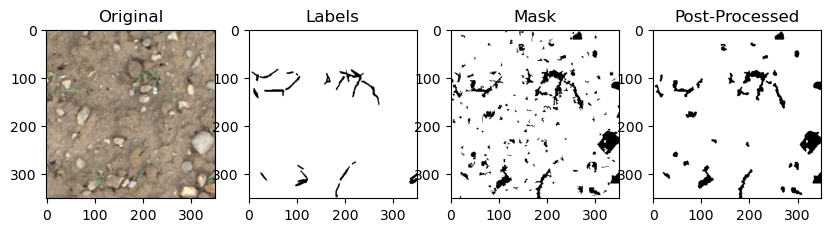

In [13]:
showResult(6, images, labels, masks, process)

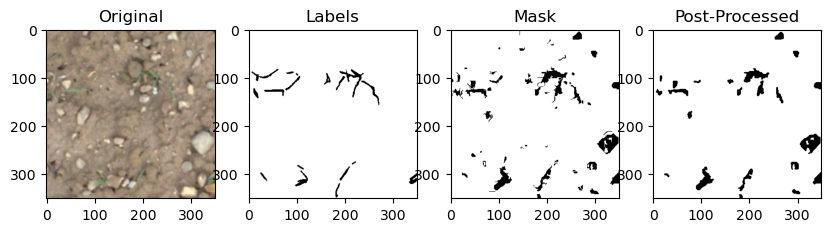

In [14]:
showResult(6, aug_imgs, aug_labels, aug_masks, aug_process)

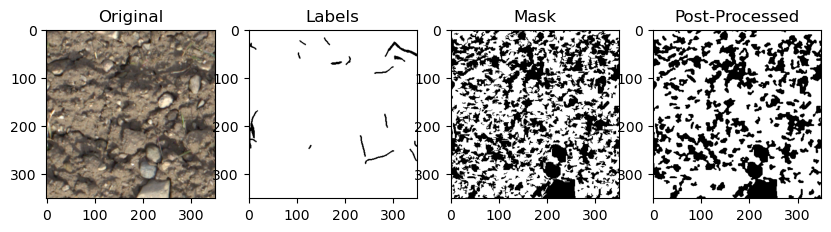

In [15]:
showResult(np.argmin(tst_stats[:, 3]), images, labels, masks, process)

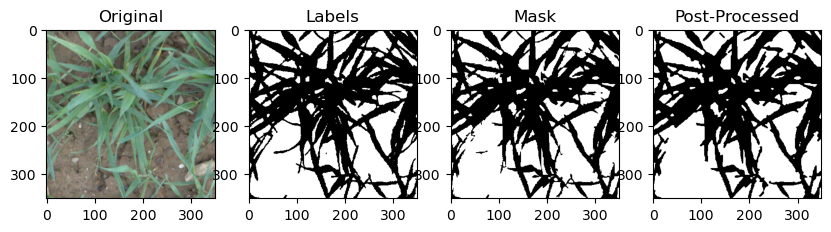

In [16]:
showResult(np.argmax(tst_stats[:, 3]), images, labels, masks, process)

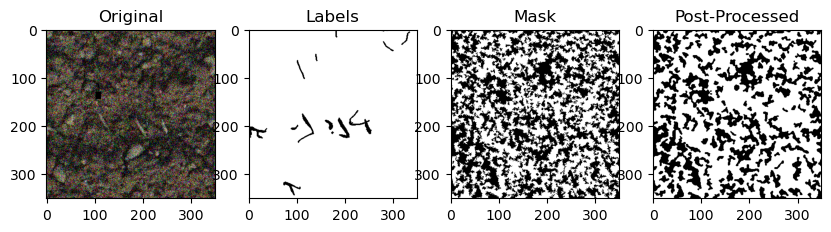

In [20]:
showResult(np.argmin(aug_tst_stats[:, 3]), aug_imgs, aug_labels, aug_masks, aug_process)

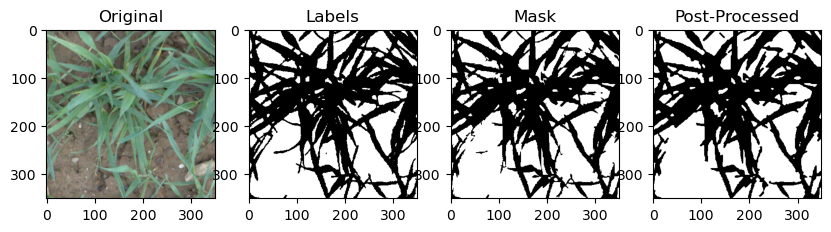

In [18]:
showResult(np.argmax(aug_tst_stats[:, 3]), aug_imgs, aug_labels, aug_masks, aug_process)